# KTP Associate Pre-Interview Data Analysis Exercise

## Question 4: How would you describe the relative performance of the two prototype formulations?

This notebook compares the two formulations directly and uses matched stress conditions to assess which one appears more stable overall.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

cols = ['start_date', 'pull_date', 'set_down_day', 'exposure_days', 'oven', 'temp_c', 'rh', 'analyst', 'assay_s1', 'assay_s2', 'imp092_s1', 'imp092_s2', 'imp123_s1', 'imp123_s2']
lot_a_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.185, 8.119, 0.288, 0.282, 0.074, 0.074], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 11.184, 10.702, 0.246, 0.215, 0.134, 0.136], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.1, 12.238, 0.222, 0.222, 0.191, 0.189], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.518, 11.095, 0.651, 0.673, 0.167, 0.171], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.813, 11.294, 0.527, 0.541, 0.176, 0.176], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.72, 11.687, 0.314, 0.289, 0.165, 0.164], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.286, 8.409, 0.51, 0.472, 0.125, 0.126], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.519, 10.643, 0.527, 0.564, 0.186, 0.184], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.34, 12.46, 0.184, 0.178, 0.198, 0.2], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.533, 12.545, 0.165, 0.165, 0.207, 0.211], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 11.912, 12.063, 0.269, 0.273, 0.194, 0.193], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 12.172, 12.178, 0.179, 0.165, 0.25, 0.246], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.281, 12.215, 0.282, 0.279, 0.297, 0.295], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.946, 11.323, 0.535, 0.544, 0.474, 0.478], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.197, 11.597, 0.573, 0.451, 0.38, 0.39], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.951, 11.909, 0.379, 0.384, 0.615, 0.621], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.039, 12.41, 0.136, 0.132, 0.386, 0.382], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.006, 12.464, 0.223, 0.211, 0.506, 0.512], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 12.15, 11.877, 0.302, 0.289, 0.748, 0.746], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.79, 12.808, 0, 0, 0.082, 0.068]]
lot_b_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.439, 7.993, 0.304, 0.287, 0.113, 0.113], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 10.463, 10.676, 0.279, 0.213, 0.207, 0.205], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.278, 12.321, 0.253, 0.241, 0.312, 0.316], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.054, 11.439, 0.737, 0.7, 0.242, 0.238], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.504, 11.413, 0.575, 0.558, 0.287, 0.291], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.653, 11.998, 0.343, 0.328, 0.271, 0.269], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.677, 8.406, 0.472, 0.491, 0.174, 0.174], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.33, 10.621, 0.52, 0.465, 0.25, 0.252], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.171, 12.14, 0.186, 0.186, 0.305, 0.309], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.308, 12.387, 0.166, 0.17, 0.309, 0.307], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 12.206, 11.714, 0.288, 0.296, 0.31, 0.316], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 11.83, 11.734, 0.19, 0.169, 0.332, 0.326], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.419, 12.228, 0.291, 0.301, 0.424, 0.432], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.829, 10.606, 0.583, 0.531, 0.546, 0.542], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.32, 11.16, 0.607, 0.576, 0.517, 0.515], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.677, 12.051, 0.454, 0.426, 0.773, 0.771], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.307, 12.258, 0.134, 0.135, 0.482, 0.48], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.137, 12.155, 0.236, 0.232, 0.658, 0.65], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 11.733, 12.053, 0.314, 0.312, 0.888, 0.882], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.493, 12.72, 0, 0, 0.143, 0.143]]
df_a = pd.DataFrame(lot_a_rows, columns=cols)
df_b = pd.DataFrame(lot_b_rows, columns=cols)
df_a['lot'] = 'A014'
df_b['lot'] = 'B025'
df = pd.concat([df_a, df_b], ignore_index=True)
for metric_name, pair_cols in {'assay':['assay_s1','assay_s2'], 'imp092':['imp092_s1','imp092_s2'], 'imp123':['imp123_s1','imp123_s2']}.items():
    df[metric_name + '_mean'] = df[pair_cols].mean(axis=1)
df['is_control'] = df['exposure_days'].eq(0)
analysis_df = df.loc[~df['is_control']].copy()
for col_name in ['temp_c', 'rh', 'exposure_days']:
    analysis_df[col_name] = pd.to_numeric(analysis_df[col_name], errors='coerce')
control_map = df.loc[df['is_control']].set_index('lot')[['assay_mean','imp092_mean','imp123_mean']].to_dict('index')
for metric_name in ['assay', 'imp092', 'imp123']:
    analysis_df[metric_name + '_delta_vs_control'] = analysis_df.apply(lambda row: row[metric_name + '_mean'] - control_map[row['lot']][metric_name + '_mean'], axis=1)
comparison_df = analysis_df.pivot_table(index=['temp_c','rh','exposure_days'], columns='lot', values=['assay_mean','imp092_mean','imp123_mean','assay_delta_vs_control','imp092_delta_vs_control','imp123_delta_vs_control'])
comparison_df.columns = ['_'.join(col_name) for col_name in comparison_df.columns]
comparison_df = comparison_df.reset_index()
comparison_df['assay_advantage_A'] = comparison_df['assay_mean_A014'] - comparison_df['assay_mean_B025']
comparison_df['imp092_advantage_A'] = comparison_df['imp092_mean_B025'] - comparison_df['imp092_mean_A014']
comparison_df['imp123_advantage_A'] = comparison_df['imp123_mean_B025'] - comparison_df['imp123_mean_A014']
comparison_df.head()


,temp_c,rh,exposure_days,assay_delta_vs_control_A014,assay_delta_vs_control_B025,assay_mean_A014,assay_mean_B025,imp092_delta_vs_control_A014,imp092_delta_vs_control_B025,imp092_mean_A014,imp092_mean_B025,imp123_delta_vs_control_A014,imp123_delta_vs_control_B025,imp123_mean_A014,imp123_mean_B025,assay_advantage_A,imp092_advantage_A,imp123_advantage_A
0,50,64,14,-0.2600,-0.2590,12.5390,12.3475,0.1650,0.1680,0.1650,0.1680,0.1340,0.165,0.2090,0.308,0.1915,0.003,0.0990
1,50,64,17,-0.3990,-0.4510,12.4000,12.1555,0.1810,0.1860,0.1810,0.1860,0.1240,0.164,0.1990,0.307,0.2445,0.005,0.1080
2,50,64,21,-0.6300,-0.3070,12.1690,12.2995,0.2220,0.2470,0.2220,0.2470,0.1150,0.171,0.1900,0.314,-0.1305,0.025,0.1240
3,60,21,14,-0.8115,-0.6465,11.9875,11.9600,0.2710,0.2920,0.2710,0.2920,0.1185,0.170,0.1935,0.313,0.0275,0.021,0.1195
4,60,21,21,-1.0955,-0.7810,11.7035,11.8255,0.3015,0.3355,0.3015,0.3355,0.0895,0.127,0.1645,0.270,-0.1220,0.034,0.1055


In [2]:
score_df = pd.DataFrame({
    'metric': ['assay_advantage_A', 'imp092_advantage_A', 'imp123_advantage_A'],
    'mean_advantage_for_A': [comparison_df['assay_advantage_A'].mean(), comparison_df['imp092_advantage_A'].mean(), comparison_df['imp123_advantage_A'].mean()],
    'median_advantage_for_A': [comparison_df['assay_advantage_A'].median(), comparison_df['imp092_advantage_A'].median(), comparison_df['imp123_advantage_A'].median()],
    'positive_condition_count_for_A': [(comparison_df['assay_advantage_A'] > 0).sum(), (comparison_df['imp092_advantage_A'] > 0).sum(), (comparison_df['imp123_advantage_A'] > 0).sum()],
    'total_conditions': [len(comparison_df), len(comparison_df), len(comparison_df)]
}).round(4)
lot_summary_df = analysis_df.groupby('lot')[['assay_mean','imp092_mean','imp123_mean']].agg(['mean', 'min', 'max']).round(3)
analysis_df['lot_code'] = analysis_df['lot'].map({'A014':0, 'B025':1})
model_rows = []
for response_name in ['assay_mean', 'imp092_mean', 'imp123_mean']:
    fit_reg = LinearRegression()
    fit_reg.fit(analysis_df[['lot_code', 'exposure_days', 'temp_c', 'rh']], analysis_df[response_name])
    pred_vals = fit_reg.predict(analysis_df[['lot_code', 'exposure_days', 'temp_c', 'rh']])
    model_rows.append({'response': response_name, 'r2': round(r2_score(analysis_df[response_name], pred_vals), 3), 'lot_code_effect': round(fit_reg.coef_[0], 4), 'days_effect': round(fit_reg.coef_[1], 4), 'temp_effect': round(fit_reg.coef_[2], 4), 'rh_effect': round(fit_reg.coef_[3], 4)})
model_df = pd.DataFrame(model_rows)
score_df
lot_summary_df
model_df


,response,r2,lot_code_effect,days_effect,temp_effect,rh_effect
0,assay_mean,0.769,-0.0893,-0.1134,-0.1474,-0.0035
1,imp092_mean,0.427,0.0186,0.0111,0.0168,0.0025
2,imp123_mean,0.819,0.1006,-0.0183,0.0044,0.0019


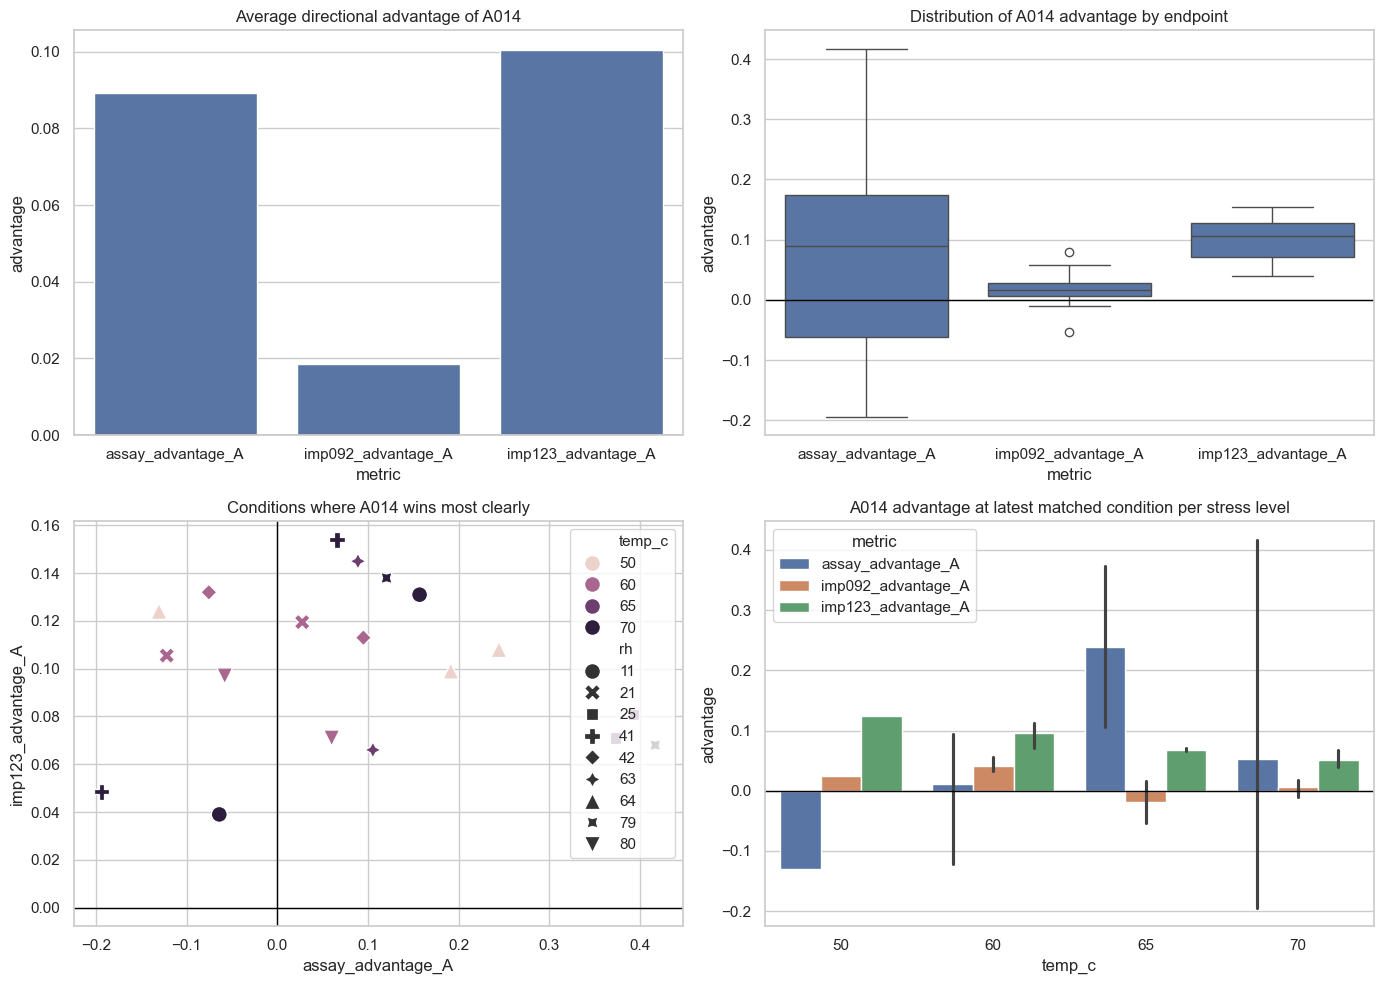

In [3]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=comparison_df.melt(value_vars=['assay_advantage_A','imp092_advantage_A','imp123_advantage_A'], var_name='metric', value_name='advantage'), x='metric', y='advantage', estimator=np.mean, errorbar=None, ax=axes[0,0])
axes[0,0].set_title('Average directional advantage of A014')
axes[0,0].axhline(0, color='black', linewidth=1)
long_pair_df = comparison_df.melt(id_vars=['temp_c','rh','exposure_days'], value_vars=['assay_advantage_A','imp092_advantage_A','imp123_advantage_A'], var_name='metric', value_name='advantage')
sns.boxplot(data=long_pair_df, x='metric', y='advantage', ax=axes[0,1])
axes[0,1].set_title('Distribution of A014 advantage by endpoint')
axes[0,1].axhline(0, color='black', linewidth=1)
sns.scatterplot(data=comparison_df, x='assay_advantage_A', y='imp123_advantage_A', hue='temp_c', style='rh', s=130, ax=axes[1,0])
axes[1,0].set_title('Conditions where A014 wins most clearly')
axes[1,0].axvline(0, color='black', linewidth=1)
axes[1,0].axhline(0, color='black', linewidth=1)
latest_df = comparison_df.sort_values('exposure_days').groupby(['temp_c','rh']).tail(1)
plot_latest_df = latest_df.melt(id_vars=['temp_c','rh'], value_vars=['assay_advantage_A','imp092_advantage_A','imp123_advantage_A'], var_name='metric', value_name='advantage')
sns.barplot(data=plot_latest_df, x='temp_c', y='advantage', hue='metric', ax=axes[1,1])
axes[1,1].set_title('A014 advantage at latest matched condition per stress level')
axes[1,1].axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


## Recommendation

The balance of evidence favours A014 as the slightly more stable formulation. Across matched conditions, A014 usually shows lower impurity formation than B025, with the clearest advantage seen for Impurity RRT 1.23. The assay comparison is more mixed, but the average difference is still small and does not outweigh the impurity advantage.

The modelling step supports the same interpretation. After accounting for exposure time, temperature, and humidity, the formulation indicator is associated with slightly lower assay and slightly higher impurity values for B025, especially for Impurity RRT 1.23.

The recommendation should still be expressed cautiously. Only one lot represents each formulation, and the dataset is too small to separate formulation effects cleanly from lot-specific behaviour. For that reason, A014 should be recommended as the better candidate for follow-up work, not as a definitively superior formulation.
